# TODO: update README <a class="anchor" id="readme"></a> 

## Important to note: May 9th, 2024
- we needed to ensure the embeddings from both models are the same, otherwise test results wrong
- problem: the DenseNet embeddings are stored in a single .npy array, whereas FM embeddings are separate .npy for each dicom
- means that the names for the DenseNet embeddings are unknown (since simply stored in array)
- separate dicoms is more ideal, since each embedding is named directly after the dicom (.jpg) that it represents 
- solution: to get around this, we used the dicoms in this file: 'MIMIC.resample.test.dicoms_nomissingJPG.csv' to read the DenseNet embeddings and FM embeddings
    - these dicoms originate here: 'mimic_cxr_densenet_embeddings.csv', which was generated at the same time as the DenseNet embeddings: 'embeddings_densenet.npy'
    - means that each row in the .npy array has its corresponding dicom_id in the metadata row
- since the FM preserved the original number of embeddings (DenseNet processing lost a few for some reason), this meant that the embeddings read-in were the same as those availabile in the DenseNet embedding array 
- this can be checked by inspecting the corresponding '_..._pca+t-SNE_.csv' files for both embedding sets: 
    - if the dicoms are the same then we can proceed with the bias analysis knowing we are working with the same images
- we are then happy to study the differences in the representations of these same images (embeddings) to identify potential bias
- TODO: we also fix the seed to 42 for sampling our 3000 subsample (1000 each race) to ensure the same embeddings are selected

## Describe
This notebook is an adaptation of this notebook: https://github.com/biomedia-mira/cxr-foundation-bias/blob/main/notebooks/chexpert.bias-inspection.cxr-foundation.ipynb
from this Github repo: https://github.com/biomedia-mira/cxr-foundation-bias/tree/main. 

Paper here: [1] https://pubs.rsna.org/doi/10.1148/ryai.230060

In that work, the authors studied this foundation model: https://github.com/Google-Health/imaging-research/tree/master/cxr-foundation to determine whether the embeddings produced by this model (i.e., penultimate convolutional feature maps prior to linear layers) encoded biases that separated disease and non-disease based on non-pathological features, such as patient age and race. 

They used the CheXpert dataset available here: https://stanfordmlgroup.github.io/competitions/chexpert/, and produced the embeddings by passing the N original JPG images (dim = [N, 224, 224]) through the model and retreiving the high-level features from the last convolutional layer (dim = [N, 1376, 1]).

Here, we examine the embeddings produced by this model on the MIMIC-CXR dataset using the same procedure in [1]. Our goal was to determine whether similarly significant biases were prevalent in this dataset, which could negatively impact our results for the hyperparameter work.

The embeddings, which were prepared by Google Health, can be retrieved from the PhysioNet archive here: https://physionet.org/content/image-embeddings-mimic-cxr/1.0/.
(access only permitted for credentialed users.)

A demo notebook for how to process and use the embeddings for downstream ML models is here: https://github.com/Google-Health/imaging-research/blob/master/cxr-foundation/MIMIC_Embeddings_Demo.ipynb.
 
## Findings
There appears to be no serious concern with regards to biasing for the MIMIC-CXR dataset. 

We do observe some statistically significant results (particularly in PCA mode-2), but not to the degree of the CheXpert embeddings (see Table 2 in [1]). The results produce similarly low prevalence of bias as observed in the benchmark model used in [1].
 
The results begin at the '[Plotting](#plots)' section. Scroll through the cell outputs to observe the PCA and t-SNE visualisations for each mode: statistical test results are provided below each marginal plot. 

[Two-sample Kolmorogov-Smirnov tests](#stats) are run at the end to establish statistical significance between subgroup comparisons.

In [137]:
import os
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

seed = 42
np.random.seed(seed)


# Unsupervised exploration of feature representations

In [138]:
root_dir = '/Users/calummaclellan/Documents/PhD/codes/mimic-cxr/src_embeddings/cxr-foundation-bias/notebooks/'
metadata_dir = root_dir + 'metadata/for-comparing-FM-DenseNet/'

In [139]:
# dataframe below for new set of test embeddings: ones that match DenseNet 'noMissingJPG.csv'
df = pd.read_csv(metadata_dir + 'MIMIC.resample.test.dicoms_nomissingJPG.csv', low_memory=False)

print(df.shape)

white = 'White'
asian = 'Asian'
black = 'Black'

(372289, 39)


In [140]:
labels = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture',
    'Support Devices']


In [141]:
model = 'densenet'
out_format = 'pdf' # use pdf for high quality vector format output
rasterized_scatter = True
out_dpi = 300

## Embeddings
Read the embeddings in from their folder and save as np array

In [142]:
embed_dir = root_dir + 'embeddings/DenseNet-embeddings/embeddings_epoch=6_May10th_v2/'

embeds = np.load(embed_dir + 'embeddings_densenet.npy')

n, m = embeds.shape
print(embeds.shape)

(372289, 1024)


In [61]:

# embeds = []

# for idx, _ in df.iterrows():
#     fn = df.loc[idx, 'embedding_array']
#     fn = embed_dir + fn
#     # line below was originally in notebook. removed as it only partially (704,) loads embeds (no idea why)
#     # embedding = np.fromfile(fn) 
#     embeds.append(embedding)
    

In [62]:
# n, m = embeds.shape
# print(embeds.shape)

### PCA

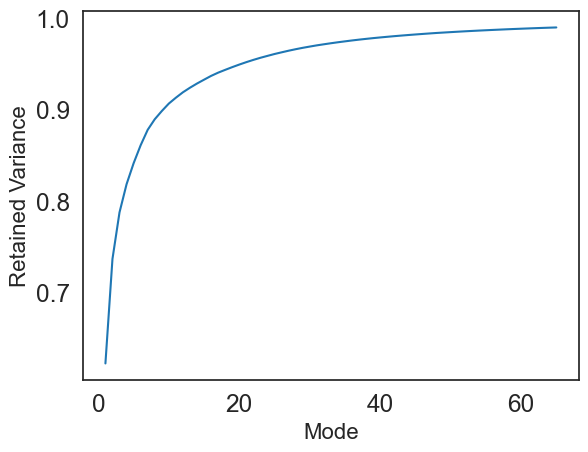

(372289, 65)


In [143]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.99, whiten=False)
embeds_pca = pca.fit_transform(embeds)

mu = pca.mean_
U = pca.components_.T
D = pca.singular_values_**2 / (n - 1)
exp_var = pca.explained_variance_ratio_

fig, ax = plt.subplots()
ax.plot(range(1,len(exp_var)+1),np.cumsum(exp_var))
ax.set_xlabel('Mode', fontsize=16)
ax.set_ylabel('Retained Variance', fontsize=16)
plt.show()

df['PCA Mode 1'] = embeds_pca[:,0]
df['PCA Mode 2'] = embeds_pca[:,1]
df['PCA Mode 3'] = embeds_pca[:,2]
df['PCA Mode 4'] = embeds_pca[:,3]

print(embeds_pca.shape)

In [144]:
print('Explained variance')
print(exp_var[:4])

Explained variance
[0.621908 0.114516 0.051040 0.030816]


### t-SNE (this may take a few minutes)

In [90]:
from sklearn.manifold import TSNE
embeds_tsne = TSNE(n_components=2, init='random', learning_rate='auto').fit_transform(embeds_pca)

df['t-SNE Dimension 1'] = embeds_tsne[:,0]
df['t-SNE Dimension 2'] = embeds_tsne[:,1]

In [145]:
df.to_csv(embed_dir + 'MIMIC.PCA.test.noMissingJPGs.densenet_embeddings.csv')
# df.to_csv(metadata_dir + 'MIMIC.PCA+TSNE.test.noMissingJPGs.pca+tsne.densenet_embeddings.csv')


### Sampling

In [192]:
df_cxr = pd.read_csv(embed_dir + 'MIMIC.PCA.test.noMissingJPGs.densenet_embeddings.csv')
# df_cxr = pd.read_csv(embed_dir + 'MIMIC.PCA+TSNE.test.noMissingJPGs.densenet_embeddings.csv')
# df_cxr = pd.read_csv(metadata_dir + 'MIMIC.test.noMissingJPGs.pca+tsne.densenet_embeddings.csv')
# df_cxr = pd.read_csv(metadata_dir + 'metadataTest_pca.csv')

df_cxr['disease'] = df_cxr[labels[0]]
df_cxr.loc[df_cxr[labels[0]] == 1, 'disease'] = labels[0]
df_cxr.loc[df_cxr[labels[10]] == 1, 'disease'] = labels[10]
df_cxr.loc[df_cxr['disease'].isna(), 'disease'] = 'Other'

df_cxr['disease_label'] = df_cxr['disease']
df_cxr.loc[df_cxr['disease_label'] == labels[0], 'disease_label'] = 0
df_cxr.loc[df_cxr['disease_label'] == labels[10], 'disease_label'] = 1
df_cxr.loc[df_cxr['disease_label'] == 'Other', 'disease_label'] = 2

df_cxr.loc[df_cxr['sex'] == 'M', 'sex'] = 'Male'
df_cxr.loc[df_cxr['sex'] == 'F', 'sex'] = 'Female'

df_cxr.to_csv(embed_dir + 'metadata.csv')

/var/folders/rz/h7cm1h2j06vbbj_t9vl0ktk80000gn/T/ipykernel_19652/1324082615.py:1: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cxr = pd.read_csv(embed_dir + 'MIMIC.PCA.test.noMissingJPGs.densenet_embeddings.csv')
/var/folders/rz/h7cm1h2j06vbbj_t9vl0ktk80000gn/T/ipykernel_19652/1324082615.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Finding' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cxr.loc[df_cxr[labels[0]] == 1, 'disease'] = labels[0]


In [147]:
n_samples = 1000

white = 'White'
asian = 'Asian'
black = 'Black'

df_white = df_cxr[df_cxr['race'] == white].sample(n=n_samples, random_state=seed)
df_asian = df_cxr[df_cxr['race'] == asian].sample(n=n_samples, random_state=seed)
df_black = df_cxr[df_cxr['race'] == black].sample(n=n_samples, random_state=seed)

sample_test = pd.concat([df_white, df_asian, df_black])

In [148]:
sample_test.to_csv(embed_dir + 'MIMIC-PCA_' + model + '_{}.embeddings.csv'.format(n_samples*3))

# Plotting <a class="anchor" id="plots"></a> 
[back to README](#readme)

In [149]:
sample_test = pd.read_csv(embed_dir + 'MIMIC-PCA_' + model + '_{}.embeddings.csv'.format(n_samples*3))
sample_test = sample_test.sample(frac=1) # shuffle data for unbiased visualisation

# Replicate entries for having capital letters in plots
sample_test['Disease'] = sample_test['disease']
sample_test['Sex'] = sample_test['sex']
sample_test['Age'] = sample_test['age']
sample_test['Race'] = sample_test['race']

In [150]:
alpha = 0.6
style = 'o'
markersize = 40
fontscale = 1.6
color_palette = 'tab10'
kind = 'scatter'

### PCA - Modes 1+2

In [151]:
method = 'pca-1+2'
xdat = 'PCA Mode 1'
ydat = 'PCA Mode 2'

#### Disease

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

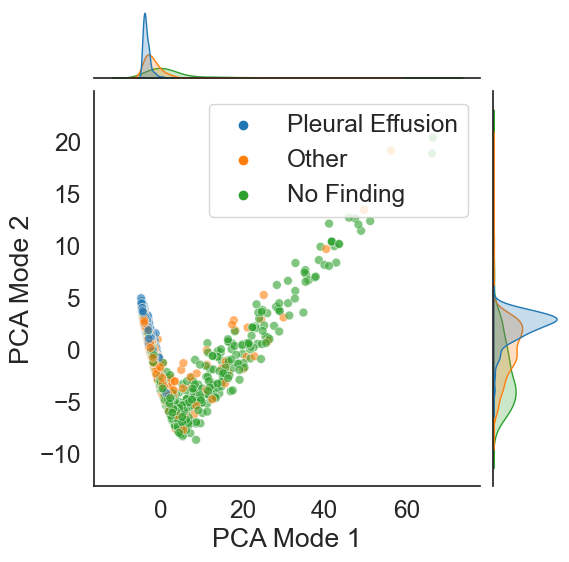

In [153]:
label = 'Disease'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, alpha=alpha, marker=style, s=markersize, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-disease.' + out_format, bbox_inches='tight', dpi=out_dpi)
xlim = fig.ax_joint.get_xlim()
ylim = fig.ax_joint.get_ylim()

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

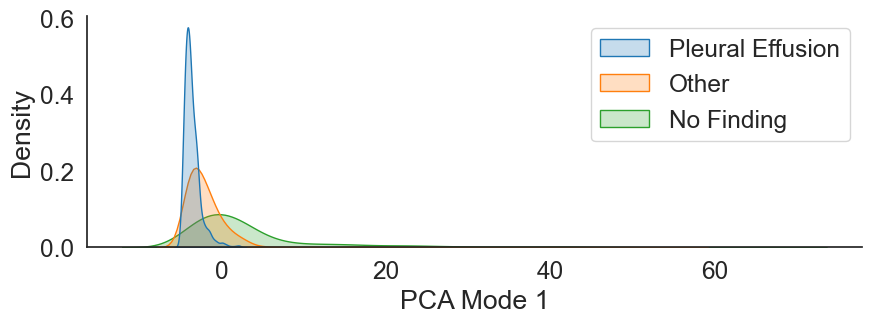

In [154]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig(embed_dir + 'pca/' + 'pca-1' + '-' + model + '-disease-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-1
Two-sample Kolmorogrov-Smirnov test: 
- No Finding vs Pleural Effusion (p-value <.0001)


This is what we wanted to see. 

For the distributions between the healthy ('No Finding') and disease ('Pleural Effusion') classes to be non-overlapping in the top principal component, this implies that the model is separating the two classes primarily based on pathology within the images. 

The t-test results above confirm that these differences are statistically significant.

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

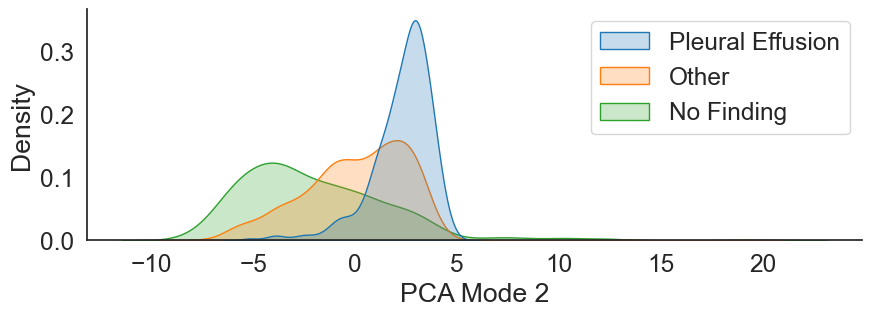

In [155]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-2' + '-' + model + '-disease-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-2
Two-sample Kolmorogrov-Smirnov test: 
- No Finding vs Pleural Effusion (p-value <.0001)

Again, we see significantly different distributions between the healthy ('No Finding') and disease ('Pleural Effusion') classes in the second-to-top component.


#### Sex

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

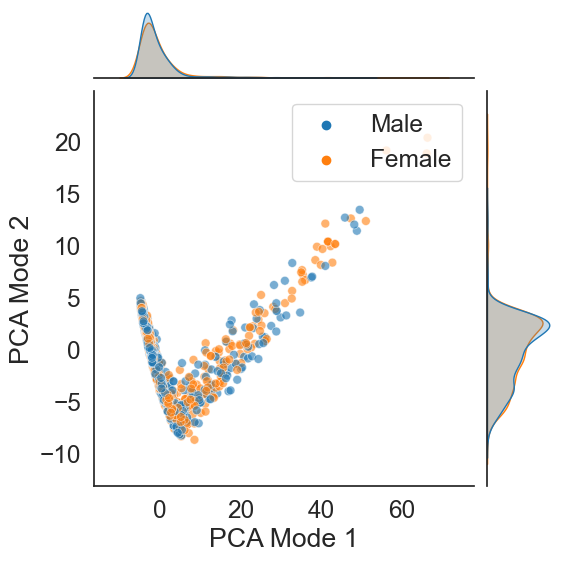

In [156]:
label = 'Sex'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, alpha=alpha, xlim=xlim, ylim=ylim, marker=style, s=markersize, hue_order=['Male', 'Female'], data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-sex.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

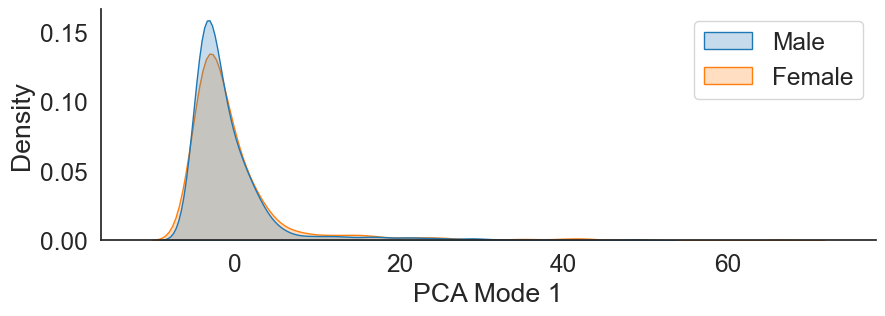

In [157]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['Male', 'Female'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig(embed_dir + 'pca/' + 'pca-1' + '-' + model + '-sex-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-1
Two-sample Kolmorogrov-Smirnov test: 
- Male vs Female (p-value = 0.0861)

This is also what we wanted to see. 

For the distributions between the Male and Female groups to be OVERLAPPING in the top principal component, this implies that the model is NOT making its predictions (i.e., classifying pathology) based on our patient's gender - which would suggest biasing exists - but rather on other factors: as we saw previously (see Disease above), these factors relate to pathology.

The t-test results above confirm that the Male-Female group differences are NOT statistically significant.

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

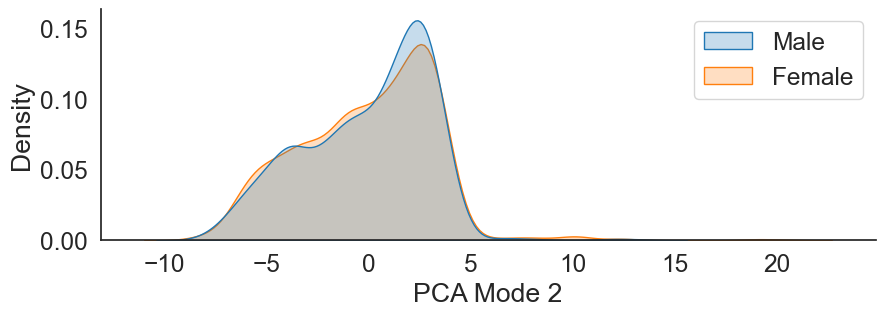

In [158]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['Male', 'Female'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-2' + '-' + model + '-sex-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-2
Two-sample Kolmorogrov-Smirnov test:
- Male vs Female (p-value = 0.00133)

#### Race

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

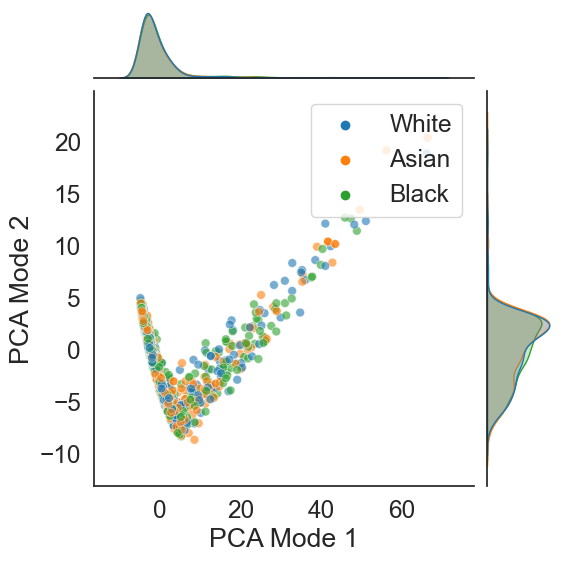

In [159]:
label = 'Race'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, xlim=xlim, ylim=ylim, marker=style, s=markersize, hue_order=['White', 'Asian', 'Black'], alpha=alpha, data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-race.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-1
Two-sample Kolmorogrov-Smirnov test:
- White vs Asian (p > .99),
- Asian vs Black (p > .99),
- Black vs White (p > .99)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

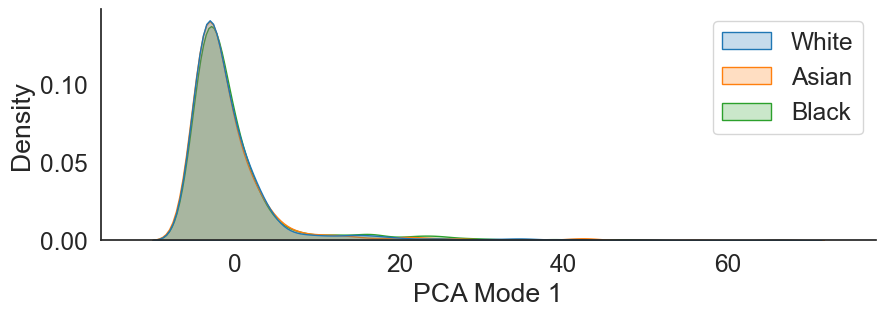

In [160]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['White', 'Asian', 'Black'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig(embed_dir + 'pca/' + 'pca-1' + '-' + model + '-race-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-2 
Two-sample Kolmorogrov-Smirnov test:
- White vs Asian (p = 0.582),
- Asian vs Black (p = 0.357),
- Black vs White (p = 0.0208)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

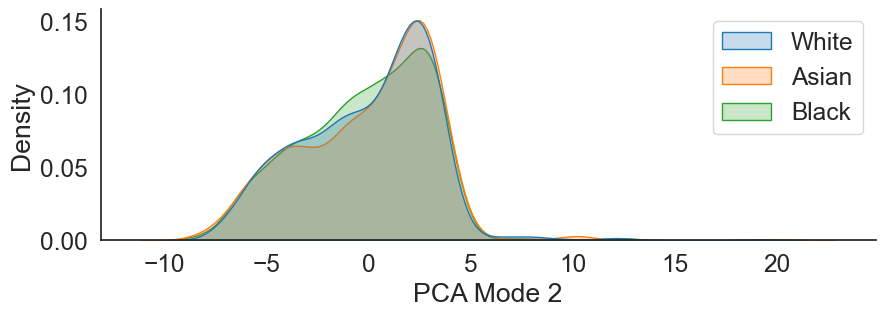

In [161]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['White', 'Asian', 'Black'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-2' + '-' + model + '-race-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

#### Age (todo statstest)

In [162]:

def bin_label(age):
    if age <= 20:
        return '20'
    if age <= 30:
        return '30'
    if age <= 40:
        return '40'
    if age <= 50:
        return '50'
    if age <= 60:
        return '60'
    if age <= 70:
        return '70'
    if age <= 80:
        return '80'
    return '90'

sample_test["age_label"] = sample_test["age"].apply(bin_label)
sample_test.age_label.sort_values().unique()

array(['20', '30', '40', '50', '60', '70', '80', '90'], dtype=object)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

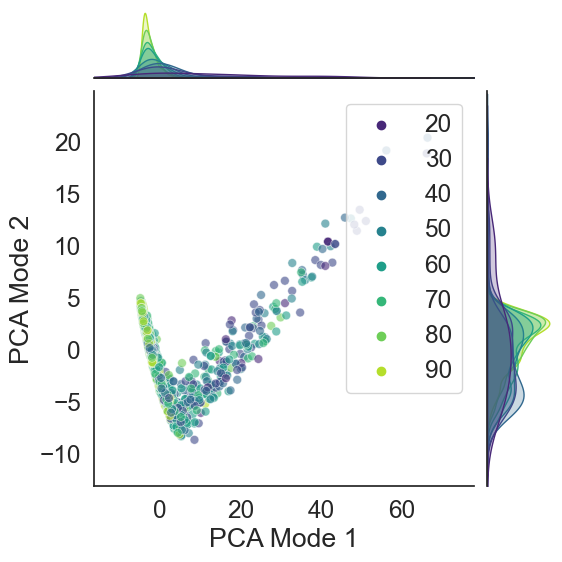

In [163]:
label = 'Age'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), alpha=alpha, xlim=xlim, ylim=ylim, marker=style, s=markersize, palette='viridis', data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-age.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

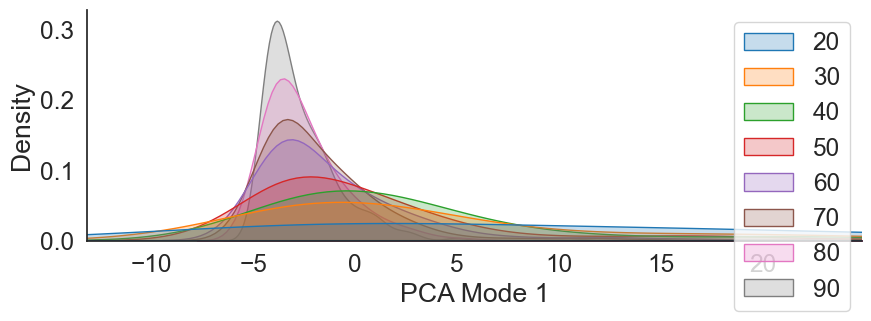

In [164]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), fill=True, data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-1' + '-' + model + '-age-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-1

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

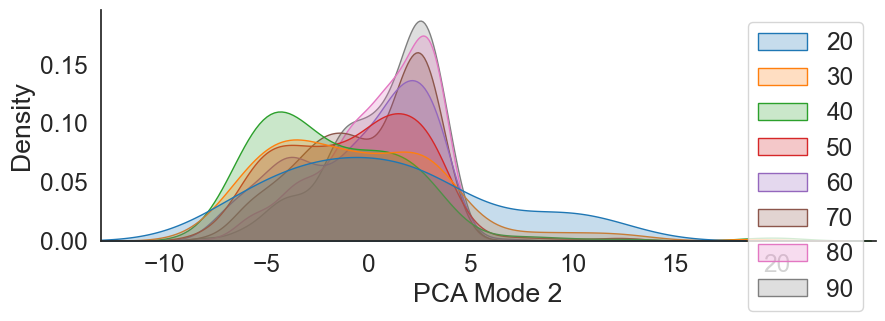

In [165]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), fill=True, data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-2' + '-' + model + '-age-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-2

### PCA - Modes 3+4

In [166]:
method = 'pca-3+4'
xdat = 'PCA Mode 3'
ydat = 'PCA Mode 4'

#### Disease

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

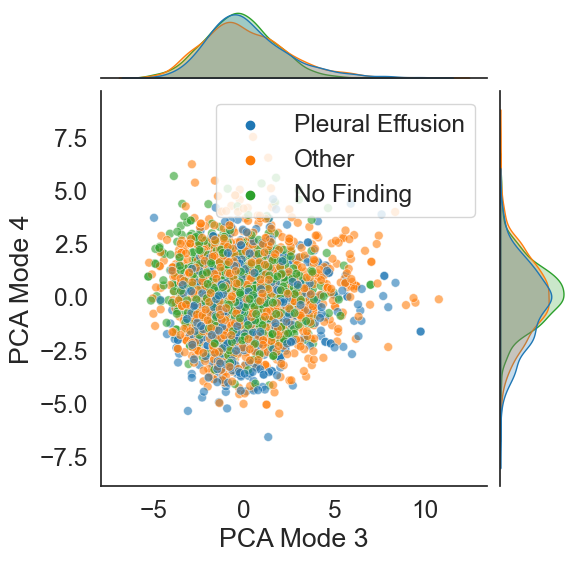

In [167]:
label = 'Disease'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, alpha=alpha, marker=style, s=markersize, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-disease.' + out_format, bbox_inches='tight', dpi=out_dpi)
xlim = fig.ax_joint.get_xlim()
ylim = fig.ax_joint.get_ylim()

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

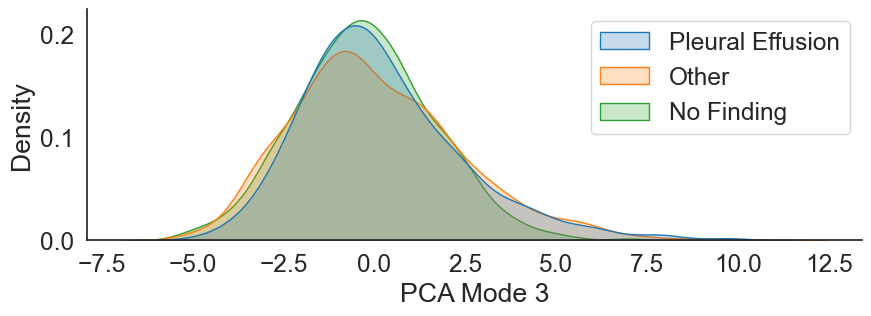

In [168]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig(embed_dir + 'pca/' + 'pca-3' + '-' + model + '-disease-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-3
Two-sample Kolmorogrov-Smirnov test:
- No Finding vs Pleural Effusion (p < .0001)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

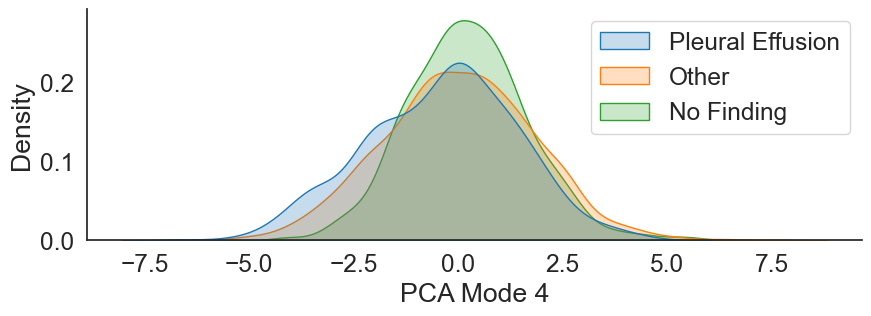

In [169]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-4' + '-' + model + '-disease-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-4
Two-sample Kolmorogrov-Smirnov test:
- No Finding vs Pleural Effusion (p < .0001)

#### Sex

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

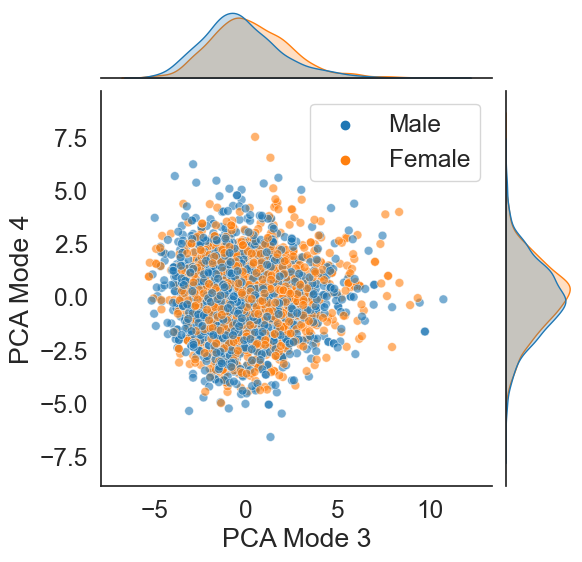

In [170]:
label = 'Sex'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, alpha=alpha, xlim=xlim, ylim=ylim, marker=style, s=markersize, hue_order=['Male', 'Female'], data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-sex.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

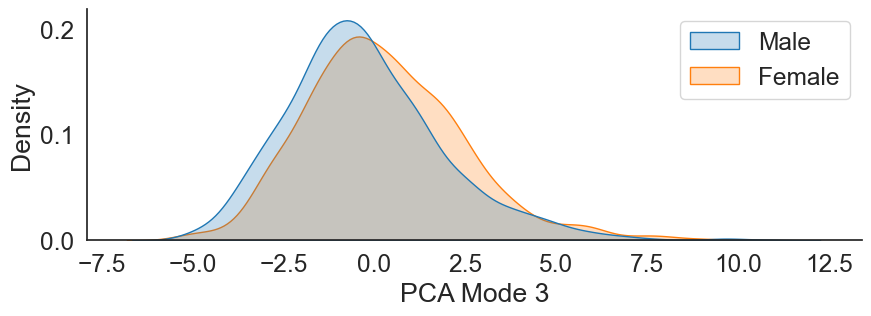

In [171]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['Male', 'Female'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig(embed_dir + 'pca/' + 'pca-3' + '-' + model + '-sex-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-3
Two-sample Kolmorogrov-Smirnov test:
- Male vs Female (p > .99)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

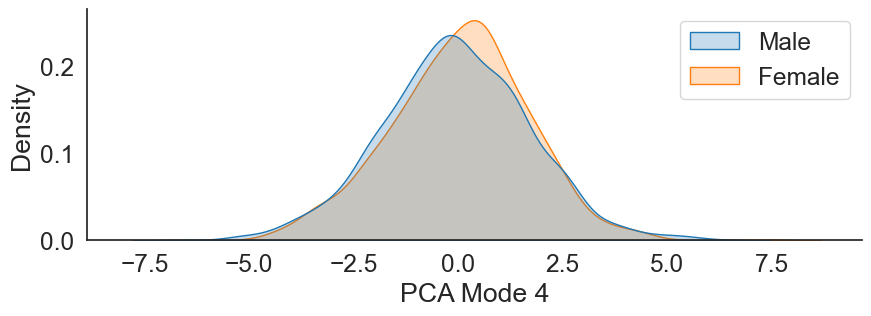

In [172]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['Male', 'Female'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-4' + '-' + model + '-sex-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-4
Two-sample Kolmorogrov-Smirnov test:
- Male vs Female (p = 0.186)

#### Race

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

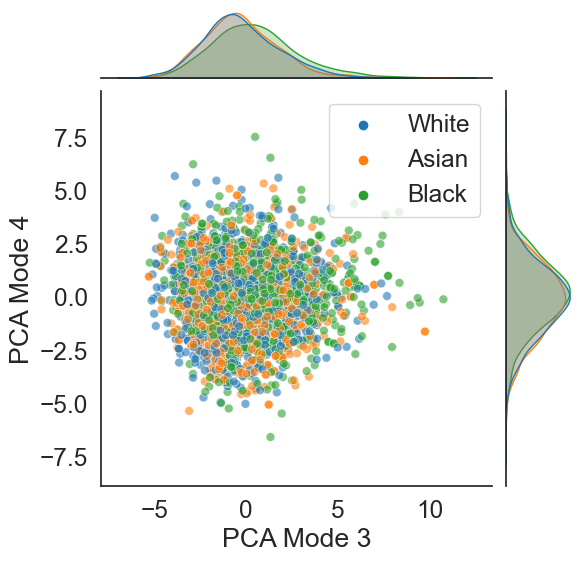

In [173]:
label = 'Race'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, xlim=xlim, ylim=ylim, marker=style, s=markersize, hue_order=['White', 'Asian', 'Black'], alpha=alpha, data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-race.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

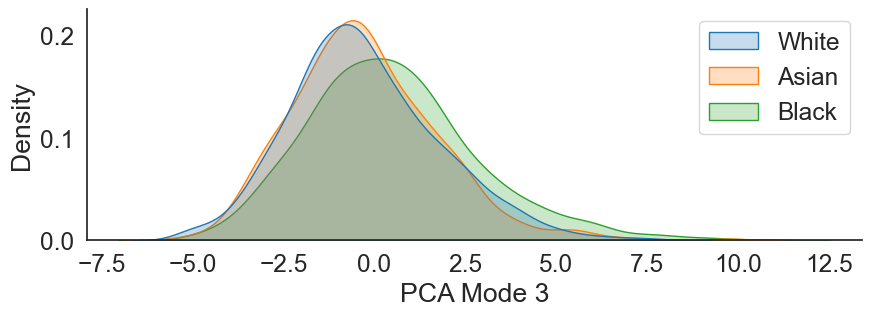

In [174]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['White', 'Asian', 'Black'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig(embed_dir + 'pca/' + 'pca-3' + '-' + model + '-race-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-3
Two-sample Kolmorogrov-Smirnov test: 
- White vs Asian (p = 0.667), 
- Asian vs Black (p = 0.00236), 
- Black vs White (p = 0.348)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

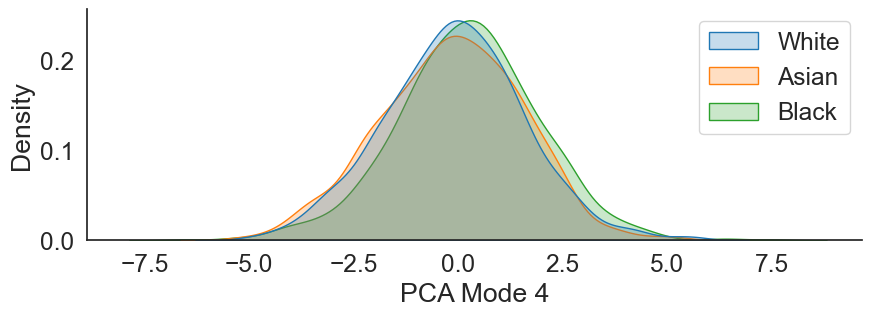

In [175]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['White', 'Asian', 'Black'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-4' + '-' + model + '-race-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-4
Two-sample Kolmorogrov-Smirnov test: 
- White vs Asian (p > .99), 
- Asian vs Black (p > .99),
- Black vs White (p > .99)

#### Age

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

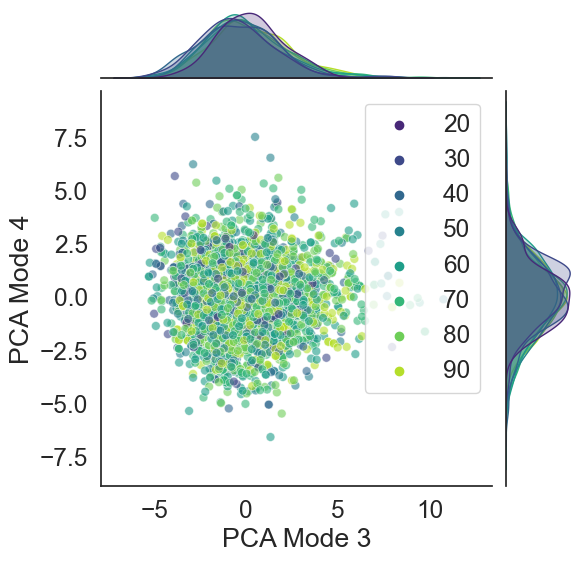

In [176]:
label = 'Age'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), alpha=alpha, xlim=xlim, ylim=ylim, marker=style, s=markersize, palette='viridis', data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(embed_dir + 'pca/' + method + '-' + model + '-age.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

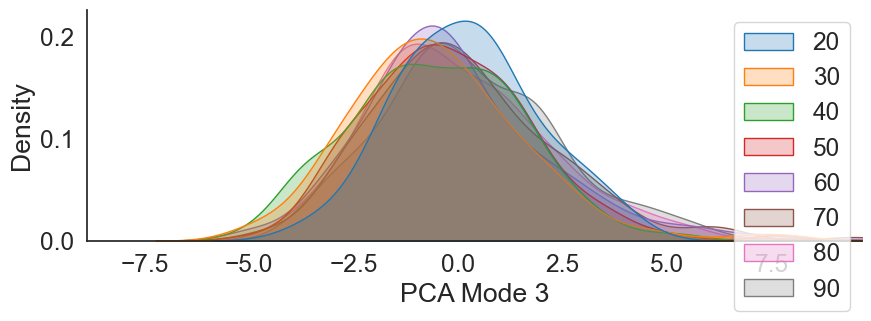

In [177]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), fill=True, data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-3' + '-' + model + '-age-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-3

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

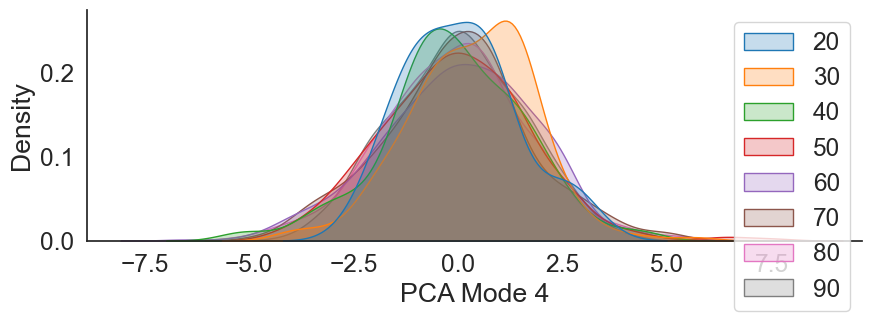

In [178]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), fill=True, data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig(embed_dir + 'pca/' + 'pca-4' + '-' + model + '-age-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

##### PCA-4

### t-SNE

In [51]:
method = 'tsne'
xdat = 't-SNE Dimension 1'
ydat = 't-SNE Dimension 2'

#### Disease

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

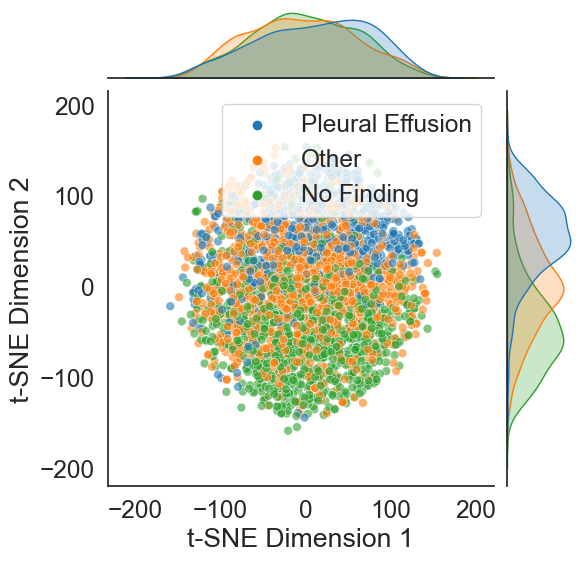

In [52]:
label = 'Disease'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, alpha=alpha, marker=style, s=markersize, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(method + '-' + model + '-disease.' + out_format, bbox_inches='tight', dpi=out_dpi)
xlim = fig.ax_joint.get_xlim()
ylim = fig.ax_joint.get_ylim()

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

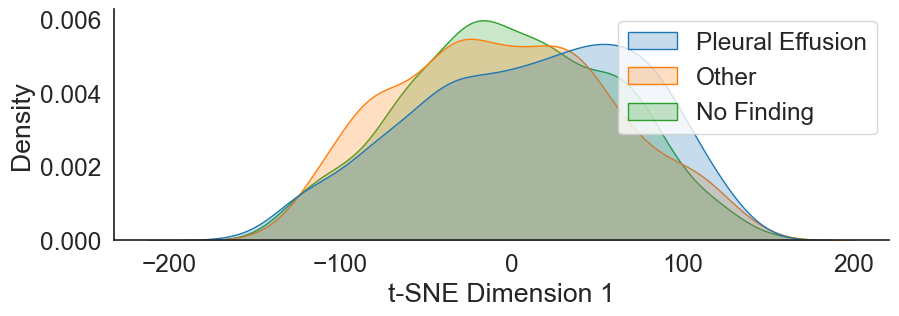

In [53]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig('tsne-1' + '-' + model + '-disease-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

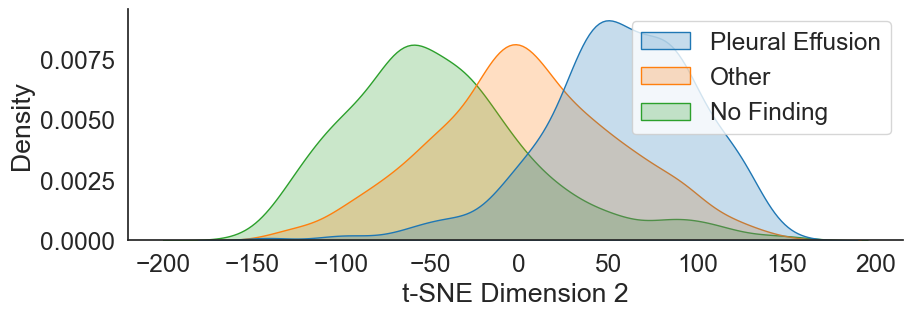

In [54]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['Pleural Effusion', 'Other', 'No Finding'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig('tsne-2' + '-' + model + '-disease-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

#### Sex

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

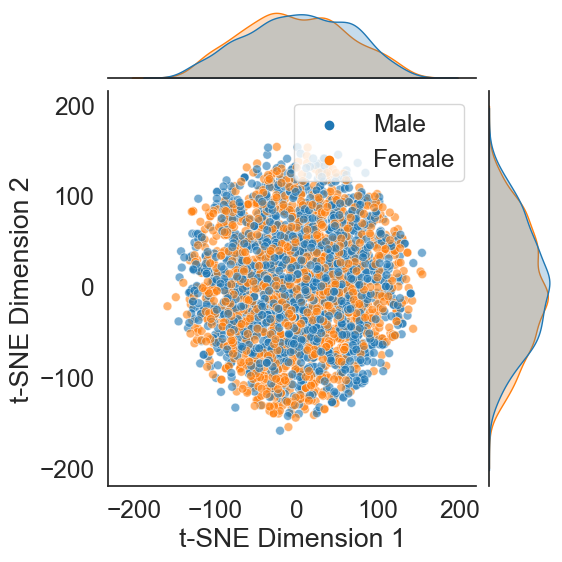

In [55]:
label = 'Sex'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, alpha=alpha, xlim=xlim, ylim=ylim, marker=style, s=markersize, hue_order=['Male', 'Female'], data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(method + '-' + model + '-sex.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

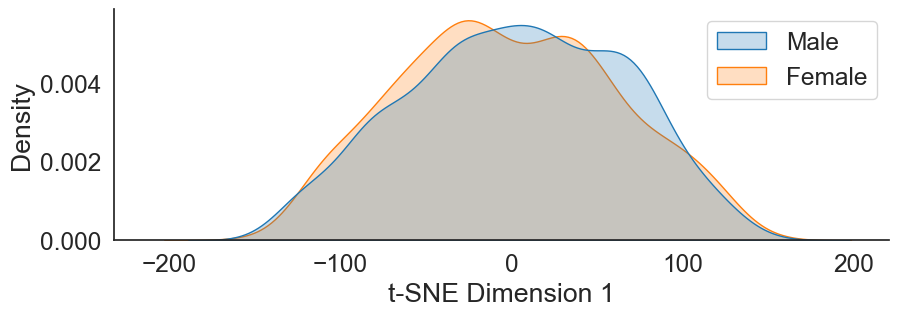

In [56]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['Male', 'Female'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig('tsne-1' + '-' + model + '-sex-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

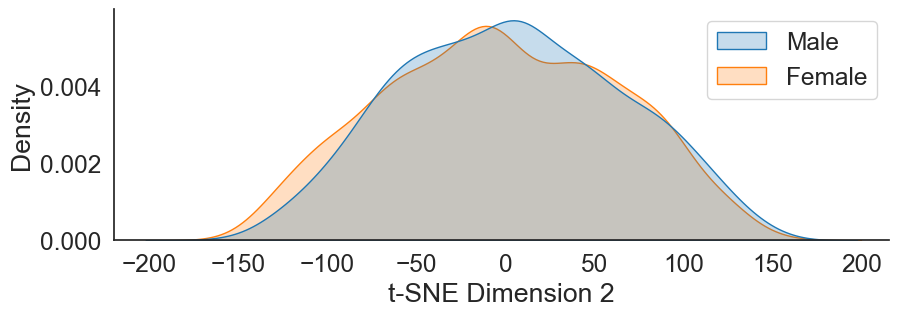

In [57]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['Male', 'Female'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig('tsne-2' + '-' + model + '-sex-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

#### Race

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

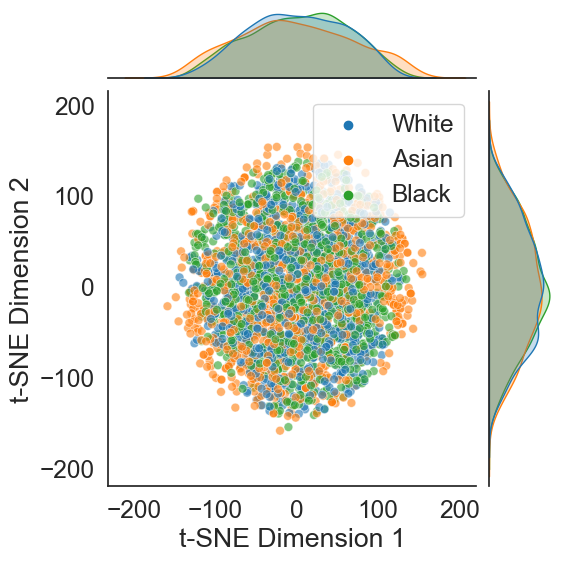

In [58]:
label = 'Race'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, kind=kind, xlim=xlim, ylim=ylim, marker=style, s=markersize, hue_order=['White', 'Asian', 'Black'], alpha=alpha, data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(method + '-' + model + '-race.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

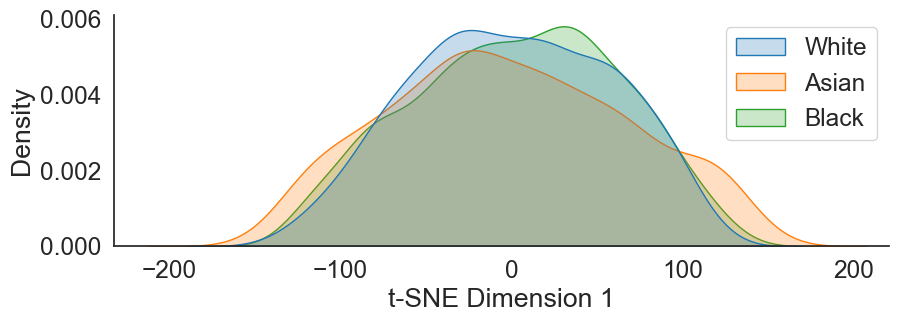

In [59]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue=label, fill=True, hue_order=['White', 'Asian', 'Black'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(xlim)
plt.savefig('tsne-1' + '-' + model + '-race-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

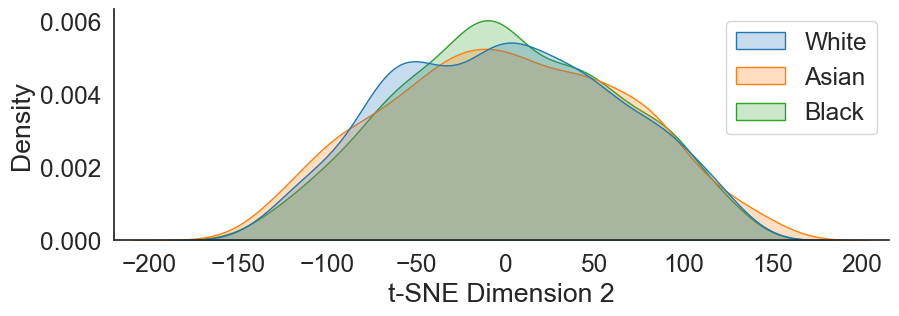

In [60]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue=label, fill=True, hue_order=['White', 'Asian', 'Black'], data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig('tsne-2' + '-' + model + '-race-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

#### Age

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

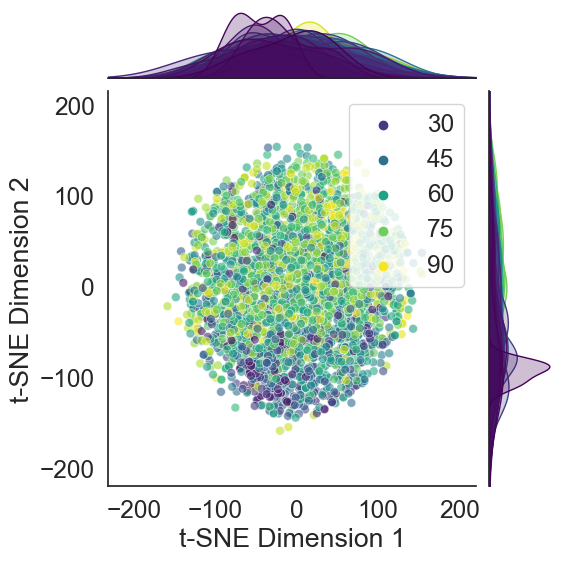

In [61]:
label = 'Age'
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig = sns.jointplot(x=xdat, y=ydat, hue=label, alpha=alpha, xlim=xlim, ylim=ylim, marker=style, s=markersize, palette='viridis', data=sample_test, joint_kws=dict(rasterized=rasterized_scatter), marginal_kws={'common_norm': False})
fig.ax_joint.legend(loc='upper right')
plt.savefig(method + '-' + model + '-age.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

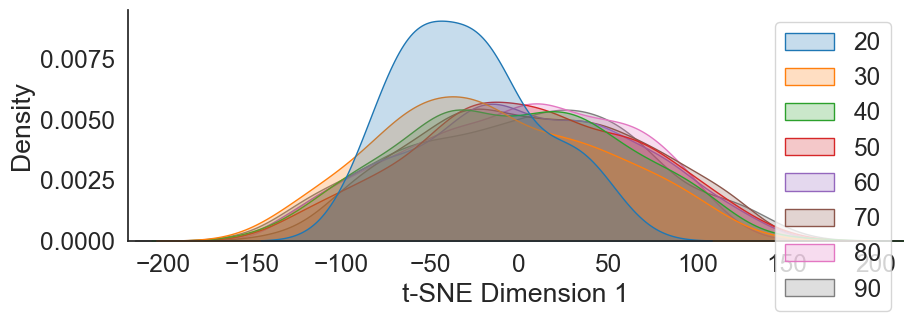

In [62]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=xdat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), fill=True, data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig('tsne-1' + '-' + model + '-age-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldc

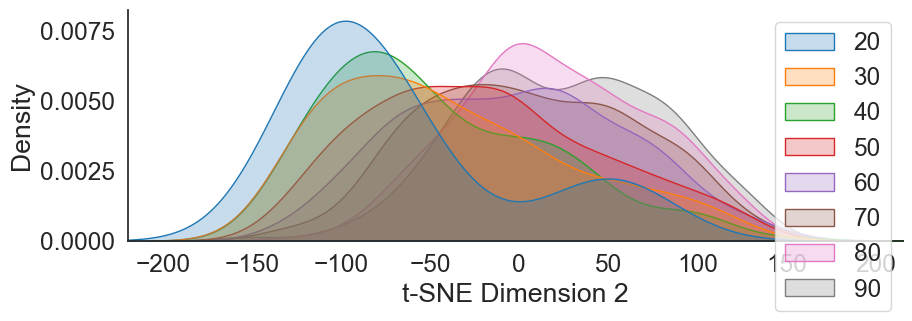

In [63]:
sns.set_theme(style="white", palette=color_palette, font_scale=fontscale)
fig, ax = plt.subplots(figsize=(10,3))
g = sns.kdeplot(x=ydat, hue='age_label', hue_order=sample_test.age_label.sort_values().unique(), fill=True, data=sample_test, ax=ax, common_norm=False)
g.get_legend().set_title(None)
g.spines[['right', 'top']].set_visible(False)
g.set_xlim(ylim)
plt.savefig('tsne-2' + '-' + model + '-age-marginal.' + out_format, bbox_inches='tight', dpi=out_dpi)

# Statistical tests <a class="anchor" id="stats"></a> 
[back to README](#readme)

In [179]:
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
np.set_printoptions(suppress=True,formatter={'float_kind': '{:4f}'.format})

In [180]:
def stats_tests(marginal, samples):
    df_white = samples[samples['race'] == white]
    df_asian = samples[samples['race'] == asian]
    df_black = samples[samples['race'] == black]
    df_female = samples[samples['sex'] == 'Female']
    df_male = samples[samples['sex'] == 'Male']
    df_nofind = samples[samples['disease_label'] == 0]
    df_pleural = samples[samples['disease_label'] == 1]

    res_np = stats.ks_2samp(np.array(df_pleural[marginal]), np.array(df_nofind[marginal]))
    res_wa = stats.ks_2samp(np.array(df_asian[marginal]), np.array(df_white[marginal]))
    res_ab = stats.ks_2samp(np.array(df_black[marginal]), np.array(df_asian[marginal]))
    res_bw = stats.ks_2samp(np.array(df_white[marginal]), np.array(df_black[marginal]))
    res_mf = stats.ks_2samp(np.array(df_female[marginal]), np.array(df_male[marginal]))

    return [res_np.pvalue, res_wa.pvalue, res_ab.pvalue, res_bw.pvalue, res_mf.pvalue]

In [181]:
pvals_pca1 = stats_tests('PCA Mode 1', sample_test)
pvals_pca2 = stats_tests('PCA Mode 2', sample_test)
pvals_pca3 = stats_tests('PCA Mode 3', sample_test)
pvals_pca4 = stats_tests('PCA Mode 4', sample_test)

In [182]:
pvals = np.array([pvals_pca1, pvals_pca2, pvals_pca3, pvals_pca4])

In [183]:
res = multipletests(pvals.flatten(), alpha=0.05, method='fdr_by', is_sorted=False, returnsorted=False)

In [184]:
print('Rejected null hypothesis')
print(np.array(res[0]).reshape((4,5)))

Rejected null hypothesis
[[ True False False False False]
 [ True False False False False]
 [False False  True  True  True]
 [ True False  True  True False]]


In [185]:
print('Adjusted p-values')
results = np.array(res[1]).reshape((4,5))
print(results)

Adjusted p-values
[[0.000000 1.000000 0.267877 0.499076 0.204612]
 [0.000000 1.000000 0.267877 0.711703 1.000000]
 [0.204612 1.000000 0.000000 0.000000 0.000000]
 [0.000000 1.000000 0.001669 0.003765 0.098821]]


# Map results to LaTeX 

In [186]:
pd.options.display.float_format = '{:.5f}'.format

pca_modes = {'PCA mode 1': results[0], 'PCA mode 2': results[1], 
             'PCA mode 3': results[2], 'PCA mode 4': results[3]}

cols = ['Mode', 'Exp. Var. (%)', 'No Finding vs Pleural Effusion', 'White vs Asian', 'Asian vs Black', 'Black vs White', 'Male vs Female']
df_pvals = pd.DataFrame(columns=cols)

df_pvals['Mode'] = pca_modes.keys()
df_pvals['Exp. Var. (%)'] = exp_var[:4]
df_pvals['No Finding vs Pleural Effusion'] = [results[0][0], results[1][0], results[2][0], results[3][0]]
df_pvals['White vs Asian'] =                 [results[0][1], results[1][1], results[2][1], results[3][1]]
df_pvals['Asian vs Black'] =                 [results[0][2], results[1][2], results[2][2], results[3][2]]
df_pvals['Black vs White'] =                 [results[0][3], results[1][3], results[2][3], results[3][3]]
df_pvals['Male vs Female'] =                 [results[0][4], results[1][4], results[2][4], results[3][4]]

display(df_pvals)

,Mode,Exp. Var. (%),No Finding vs Pleural Effusion,White vs Asian,Asian vs Black,Black vs White,Male vs Female
0,PCA mode 1,0.62191,0.00000,1.00000,0.26788,0.49908,0.20461
1,PCA mode 2,0.11452,0.00000,1.00000,0.26788,0.71170,1.00000
2,PCA mode 3,0.05104,0.20461,1.00000,0.00000,0.00000,0.00000
3,PCA mode 4,0.03082,0.00000,1.00000,0.00167,0.00377,0.09882


In [67]:
print(df_pvals.to_latex(index=False,
                        formatters={"name": str.upper},
                        float_format="{:.4f}".format,
)) 

\begin{tabular}{lrrrrrr}
\toprule
Mode & Exp. Var. (%) & No Finding vs Pleural Effusion & White vs Asian & Asian vs Black & Black vs White & Male vs Female \\
\midrule
PCA mode 1 & 0.1917 & 0.0000 & 1.0000 & 1.0000 & 1.0000 & 0.0861 \\
PCA mode 2 & 0.1171 & 0.0000 & 0.5823 & 0.3573 & 0.0209 & 0.0013 \\
PCA mode 3 & 0.0519 & 0.0000 & 0.6671 & 0.0024 & 0.3482 & 1.0000 \\
PCA mode 4 & 0.0486 & 0.0000 & 1.0000 & 1.0000 & 1.0000 & 0.1869 \\
\bottomrule
\end{tabular}



# Per-pathology classification performance
Here we determine the accuracy of the model given the predictions and corresponding targets for each pathology.

Also a good place to study the subsample performance across our race groups. 


First job: load in the targets and predictions we obtained over the whole resampled test dataset (~370k)

In [212]:
df_targets = pd.read_csv(embed_dir + 'targets.csv')
df_predictions = pd.read_csv(embed_dir + 'predictions.csv')
df_metadata = pd.read_csv(embed_dir + 'metadata.csv')
df_metadata = df_metadata[['subject_id', 'dicom_id', 'sex', 'race']]
print(df_metadata.columns)
print(df_targets.columns)

# prepare df_targets and df_predictions for upcoming loops
df_targets = df_targets[labels] 
# assert (df_targets.loc[df_targets['subject_id'].isin(df_metadata['subject_id'])])

df_targets[['sex', 'race']] = df_metadata[['sex', 'race']]
df_predictions = df_predictions[labels]
df_predictions[['sex', 'race']] = df_metadata[['sex', 'race']]

print(df_metadata.shape)
print(df_targets.shape)


Index(['subject_id', 'dicom_id', 'sex', 'race'], dtype='object')
Index(['Unnamed: 0', 'No Finding', 'Enlarged Cardiomediastinum',
       'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
       'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
       'Pleural Other', 'Fracture', 'Support Devices', 'subject_id',
       'dicom_id'],
      dtype='object')
(372289, 4)
(372289, 16)


/var/folders/rz/h7cm1h2j06vbbj_t9vl0ktk80000gn/T/ipykernel_19652/3419485928.py:3: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_metadata = pd.read_csv(embed_dir + 'metadata.csv')


## Race

In [230]:
race_labels = ['Asian', 'White', 'Black']
print(race_labels)

['Asian', 'White', 'Black']


Now iterate over each race and compute the performance metrics across all pathologies.

Repeat for different thresholds (0.25, 0.5, 0.75): lower means we place a tighter bound on the recall (i.e., higher TPR but also higher FPR since more positive results); higher means we expect less positive results but create a more sensitive classifier (ie it takes far greater evidence to generate a positive result, in contrast to allowing basically any probability to be rounded to 1 which produces a weak classifier.)

In [235]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score

thresholds = [0.25, 0.50, 0.75]
df_all_results_race = pd.DataFrame()

for th in thresholds:

    for label in labels:

        # print('Evaluating {} predictions...'.format(label))

        df_results = pd.DataFrame()
        # auc, ppv, tpr, fpr = [], [], [], [] # use for append in bootstrap case: not done here for quickness (+ tiny CI in Glocker anyway)

        for race in race_labels:

            # pull out the predictions for this pathology label and race
            preds = df_predictions[label].loc[df_predictions['race']==race]
            # pull out the targets for this pathology label and race
            targets = df_targets[label].loc[df_targets['race']==race]

            # compute performance
            auc = roc_auc_score(targets, preds)
            ppv = precision_score(targets, preds>=th)
            tpr = recall_score(targets, preds>=th, pos_label=1)
            fpr = 1-recall_score(targets, preds>=th, pos_label=0)

            # store results
            df_race = pd.DataFrame({'AUC':[auc], 'precision':[ppv], 'recall':[tpr], 'FPR':[fpr]})
            df_race['pathology'] = label
            df_race['race'] = race
            df_race['threshold'] = th
        
            df_results = pd.concat([df_results, df_race], ignore_index=True)
            
        df_all_results_race = pd.concat([df_all_results_race, df_results], ignore_index=True)

display(df_all_results_race)
# df_results.to_csv(os.path.join('./{}_performance_stats.csv').format(label))
    


/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classi

,AUC,precision,recall,FPR,pathology,race,threshold
0,0.84754,0.65504,0.75602,0.19921,No Finding,Asian,0.25000
1,0.84887,0.64682,0.76260,0.20830,No Finding,White,0.25000
2,0.85574,0.63686,0.80055,0.22914,No Finding,Black,0.25000
3,0.74675,0.63462,0.05131,0.00106,Enlarged Cardiomediastinum,Asian,0.25000
4,0.73411,0.20497,0.02089,0.00283,Enlarged Cardiomediastinum,White,0.25000
...,...,...,...,...,...,...,...
121,0.67494,0.00000,0.00000,0.00000,Fracture,White,0.75000
122,0.60873,0.00000,0.00000,0.00000,Fracture,Black,0.75000
123,0.88021,0.81739,0.39724,0.03947,Support Devices,Asian,0.75000
124,0.87574,0.80890,0.40845,0.04390,Support Devices,White,0.75000


In [241]:
print('Threshold = 0.25')
print()
print(df_all_results_race.loc[(df_all_results_race['pathology']=='No Finding') & (df_all_results_race['threshold']==0.25)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Cardiomegaly') & (df_all_results_race['threshold']==0.25)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Pleural Effusion') & (df_all_results_race['threshold']==0.25)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Atelectasis') & (df_all_results_race['threshold']==0.25)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Pneumothorax') & (df_all_results_race['threshold']==0.25)])

print('Threshold = 0.5')
print()
print(df_all_results_race.loc[(df_all_results_race['pathology']=='No Finding') & (df_all_results_race['threshold']==0.5)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Cardiomegaly') & (df_all_results_race['threshold']==0.5)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Pleural Effusion') & (df_all_results_race['threshold']==0.5)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Atelectasis') & (df_all_results_race['threshold']==0.5)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Pneumothorax') & (df_all_results_race['threshold']==0.5)])

print('Threshold = 0.75')
print()
print(df_all_results_race.loc[(df_all_results_race['pathology']=='No Finding') & (df_all_results_race['threshold']==0.75)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Cardiomegaly') & (df_all_results_race['threshold']==0.75)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Pleural Effusion') & (df_all_results_race['threshold']==0.75)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Atelectasis') & (df_all_results_race['threshold']==0.75)])
print(df_all_results_race.loc[(df_all_results_race['pathology']=='Pneumothorax') & (df_all_results_race['threshold']==0.75)])

Threshold = 0.25

      AUC  precision  recall     FPR   pathology   race  threshold
0 0.84754    0.65504 0.75602 0.19921  No Finding  Asian    0.25000
1 0.84887    0.64682 0.76260 0.20830  No Finding  White    0.25000
2 0.85574    0.63686 0.80055 0.22914  No Finding  Black    0.25000
      AUC  precision  recall     FPR     pathology   race  threshold
6 0.80229    0.42577 0.66175 0.23341  Cardiomegaly  Asian    0.25000
7 0.79702    0.37032 0.70493 0.27269  Cardiomegaly  White    0.25000
8 0.81967    0.47524 0.75237 0.26654  Cardiomegaly  Black    0.25000
       AUC  precision  recall     FPR         pathology   race  threshold
30 0.90298    0.54080 0.88526 0.23880  Pleural Effusion  Asian    0.25000
31 0.89195    0.53353 0.86819 0.23774  Pleural Effusion  White    0.25000
32 0.90329    0.57510 0.83702 0.19297  Pleural Effusion  Black    0.25000
       AUC  precision  recall     FPR    pathology   race  threshold
24 0.81277    0.35299 0.81417 0.33148  Atelectasis  Asian    0.25000
25 0

## Sex

In [231]:
sex_labels = ['Male', 'Female']

In [239]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score

df_all_results_sex = pd.DataFrame()

for th in thresholds:
        
    for label in labels:

        # print('Evaluating {} predictions...'.format(label))

        df_results = pd.DataFrame()
        # auc, ppv, tpr, fpr = [], [], [], [] # use for append in bootstrap case: not done here for quickness (+ tiny CI in Glocker anyway)

        for sex in sex_labels:

            # pull out the predictions for this pathology label and race
            preds = df_predictions[label].loc[df_predictions['sex']==sex]
            # pull out the targets for this pathology label and race
            targets = df_targets[label].loc[df_targets['sex']==sex]

            # compute performance
            auc = roc_auc_score(targets, preds)
            ppv = precision_score(targets, preds>=th)
            tpr = recall_score(targets, preds>=th, pos_label=1)
            fpr = 1-recall_score(targets, preds>=th, pos_label=0)

            # store results
            df_sex = pd.DataFrame({'AUC':[auc], 'precision':[ppv], 'recall':[tpr], 'FPR':[fpr]})
            df_sex['pathology'] = label
            df_sex['sex'] = sex
            df_sex['threshold'] = th
        
            df_results = pd.concat([df_results, df_sex], ignore_index=True)
            
        df_all_results_sex = pd.concat([df_all_results_sex, df_results], ignore_index=True)

display(df_all_results_sex)
# df_results.to_csv(os.path.join('./{}_performance_stats.csv').format(label))
    


/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/sklearn/metrics/_classi

,AUC,precision,recall,FPR,pathology,sex,threshold
0,0.84866,0.61437,0.77448,0.21774,No Finding,Male,0.25000
1,0.85669,0.67197,0.80027,0.22545,No Finding,Female,0.25000
2,0.73845,0.21812,0.02886,0.00367,Enlarged Cardiomediastinum,Male,0.25000
3,0.74297,0.45477,0.03638,0.00128,Enlarged Cardiomediastinum,Female,0.25000
4,0.80138,0.40210,0.69477,0.25703,Cardiomegaly,Male,0.25000
...,...,...,...,...,...,...,...
79,0.82277,0.00000,0.00000,0.00000,Pleural Other,Female,0.75000
80,0.65332,0.00000,0.00000,0.00000,Fracture,Male,0.75000
81,0.66357,0.00000,0.00000,0.00000,Fracture,Female,0.75000
82,0.88282,0.80797,0.43849,0.05193,Support Devices,Male,0.75000


In [242]:

print('threshold = 0.25')
print()
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='No Finding') & (df_all_results_sex['threshold']==0.25)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Cardiomegaly') & (df_all_results_sex['threshold']==0.25)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Pleural Effusion') & (df_all_results_sex['threshold']==0.25)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Atelectasis') & (df_all_results_sex['threshold']==0.25)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Pneumothorax') & (df_all_results_sex['threshold']==0.25)])

print('threshold = 0.5')
print()
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='No Finding') & (df_all_results_sex['threshold']==0.5)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Cardiomegaly') & (df_all_results_sex['threshold']==0.5)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Pleural Effusion') & (df_all_results_sex['threshold']==0.5)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Atelectasis') & (df_all_results_sex['threshold']==0.5)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Pneumothorax') & (df_all_results_sex['threshold']==0.5)])

print('threshold = 0.75')
print()
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='No Finding') & (df_all_results_sex['threshold']==0.75)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Cardiomegaly') & (df_all_results_sex['threshold']==0.75)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Pleural Effusion') & (df_all_results_sex['threshold']==0.75)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Atelectasis') & (df_all_results_sex['threshold']==0.75)])
print(df_all_results_sex.loc[(df_all_results_sex['pathology']=='Pneumothorax') & (df_all_results_sex['threshold']==0.75)])

threshold = 0.25

      AUC  precision  recall     FPR   pathology     sex  threshold
0 0.84866    0.61437 0.77448 0.21774  No Finding    Male    0.25000
1 0.85669    0.67197 0.80027 0.22545  No Finding  Female    0.25000
      AUC  precision  recall     FPR     pathology     sex  threshold
4 0.80138    0.40210 0.69477 0.25703  Cardiomegaly    Male    0.25000
5 0.81811    0.44168 0.71476 0.24929  Cardiomegaly  Female    0.25000
       AUC  precision  recall     FPR         pathology     sex  threshold
20 0.89193    0.54498 0.85284 0.22832  Pleural Effusion    Male    0.25000
21 0.91177    0.55916 0.87222 0.20432  Pleural Effusion  Female    0.25000
       AUC  precision  recall     FPR    pathology     sex  threshold
16 0.79419    0.37661 0.76719 0.32645  Atelectasis    Male    0.25000
17 0.79824    0.34707 0.76055 0.30662  Atelectasis  Female    0.25000
       AUC  precision  recall     FPR     pathology     sex  threshold
18 0.82645    0.37751 0.31131 0.02833  Pneumothorax    Male   